# Assignment no.02
## NLP
- --
#### Name: Ayesha Amer
#### Roll no. 23i-2503
#### Section: DS-6C
- --
### Libraries Loading

In [1]:
#importing all required libraries
import os
import json
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

### Data Loading

In [6]:
#loading cleaned.txt
f = open('cleaned.txt', 'r', encoding='utf-8')
cleaned_text = f.read()
f.close()

#loading raw.txt
f = open('raw.txt', 'r', encoding='utf-8')
raw_text = f.read()
f.close()

#loading metadata
f = open('Metadata.json', 'r', encoding='utf-8')
metadata = json.load(f)
f.close()

print('cleaned text length:', len(cleaned_text))
print('raw text length:', len(raw_text))
print('metadata entries:', len(metadata))

cleaned text length: 2132293
raw text length: 2170160
metadata entries: 275


- --
## Part 1 : Word Embeddings
## 1.1: TF-IDF
- Creatig a Documents List.

In [9]:
#splitting cleaned text into documents
documents = []
for line in cleaned_text.strip().split('\n'):
    line = line.strip()
    #removing the article heading
    if len(line) > 0 and not line.startswith('Article'):
        documents.append(line)

print('total documents:', len(documents))

#printing
for i in range(min(3, len(documents))):
    print('document', i+1, ':', documents[i][:150])

total documents: 17326
document 1 : انڈیا سے پاکستان آ کر شادی کرنے والی خاتون سربجیت کور نور فاطمہ نے کہا ہے کہ وہ اپنی باقی ماندہ زندگی پاکستان میں ہی ہنسی خوشی گزارنا چاہتا ہیں اور وہ
document 2 : وسطی پنجاب کے ضلع شیخوپورہ میں اپنے وکیل احمد حسن پاشا کے چیمبر میں میڈیا کے نمائند سے گفتگو کرتے ہوئے سربجیت کور نور فاطمہ کا مزید کہنا تھا کہ میں او
document 3 : ہم پیار کرتے ہوئے آٹھ سال ہو گئے تھے اور یہ یقین تھا کہ ہم دون کبھی نہ کبھی تو ضرور مل گے ۔


- Tokenizing

In [12]:
#tokenizing all documents
tokenized_docs = []
for doc in documents:
    tokens = doc.split()
    tokenized_docs.append(tokens)

print('total tokenized documents:', len(tokenized_docs))
print('first document tokens:', tokenized_docs[0][:15])
print('second document tokens:', tokenized_docs[1][:15])
print('third document tokens:', tokenized_docs[2][:15])

total tokenized documents: 17326
first document tokens: ['انڈیا', 'سے', 'پاکستان', 'آ', 'کر', 'شادی', 'کرنے', 'والی', 'خاتون', 'سربجیت', 'کور', 'نور', 'فاطمہ', 'نے', 'کہا']
second document tokens: ['وسطی', 'پنجاب', 'کے', 'ضلع', 'شیخوپورہ', 'میں', 'اپنے', 'وکیل', 'احمد', 'حسن', 'پاشا', 'کے', 'چیمبر', 'میں', 'میڈیا']
third document tokens: ['ہم', 'پیار', 'کرتے', 'ہوئے', 'آٹھ', 'سال', 'ہو', 'گئے', 'تھے', 'اور', 'یہ', 'یقین', 'تھا', 'کہ', 'ہم']


- Building Vocabulary

In [13]:
#counting word frequencies across all documents
all_words = []
for tokens in tokenized_docs:
    for token in tokens:
        all_words.append(token)

word_counts = Counter(all_words)

print('total words collected:', len(all_words))
print('unique words:', len(word_counts))
print('top 10 most common words:')
for i, (word, count) in enumerate(word_counts.most_common(10)):
    print(' ', i+1, ':', word, '->', count, 'times')

total words collected: 491022
unique words: 13495
top 10 most common words:
  1 : کے -> 20937 times
  2 : ۔ -> 16642 times
  3 : میں -> 14364 times
  4 : کی -> 13437 times
  5 : ہے -> 9924 times
  6 : سے -> 9697 times
  7 : اور -> 9465 times
  8 : کہ -> 8507 times
  9 : کا -> 7431 times
  10 : نے -> 7032 times


In [15]:
#restricting vocabulary to top 10000 tokens
vocab_size = 10000
most_common = word_counts.most_common(vocab_size)
vocab = ['<UNK>']
for word, count in most_common:
    vocab.append(word)

word_to_index = {}
for i in range(len(vocab)):
    word_to_index[vocab[i]] = i

print('vocabulary size:', len(vocab))
print('first 10 words in vocab:')
for i in range(min(10, len(vocab))):
    print(' ', i, ':', vocab[i])

vocabulary size: 10001
first 10 words in vocab:
  0 : <UNK>
  1 : کے
  2 : ۔
  3 : میں
  4 : کی
  5 : ہے
  6 : سے
  7 : اور
  8 : کہ
  9 : کا


- TF for each Doc

In [17]:
num_docs = len(tokenized_docs)
num_vocab = len(vocab)

print('number of documents:', num_docs)
print('vocabulary size:', num_vocab)

#building term-document matrix
tf_matrix = np.zeros((num_vocab, num_docs))

for doc_idx in range(num_docs):
    #getting the current document
    tokens = tokenized_docs[doc_idx]

    #counting how many times each word appears in this document
    token_count = Counter(tokens)
    total_tokens = len(tokens)

    for token in token_count:
        if token in word_to_index:
            word_idx = word_to_index[token]
        else:
            word_idx = word_to_index['<UNK>']
        tf_matrix[word_idx][doc_idx] = token_count[token] / total_tokens

print('tf matrix shape:', tf_matrix.shape)
print('tf value for word at index 1 in doc 0:', tf_matrix[1][0])

number of documents: 17326
vocabulary size: 10001
tf matrix shape: (10001, 17326)
tf value for word at index 1 in doc 0: 0.024390243902439025


- DF for each word

In [18]:
#computing document frequency  for each word
df = np.zeros(num_vocab)
for word_idx in range(num_vocab):
    count = 0
    for doc_idx in range(num_docs):
        if tf_matrix[word_idx][doc_idx] > 0:
            count = count + 1
    df[word_idx] = count

print('DF complete')
print('word index 1 appears in', df[1], 'documents')
print('unknown token appears in', df[0], 'documents')

DF complete
word index 1 appears in 11314.0 documents
unknown token appears in 2531.0 documents


- IDF

In [19]:
#computing idf
idf = np.zeros(num_vocab)
for word_idx in range(num_vocab):
    idf[word_idx] = math.log(num_docs / (1 + df[word_idx]))

print('idf complete')
print('idf for word index 1 is', round(idf[1], 4))
print('idf for unknown token is', round(idf[0], 4))

idf complete
idf for word index 1 is 0.4261
idf for unknown token is 1.9232


- TF_IDF matrix

In [20]:
#computing tfidf matrix
tfidf_matrix = np.zeros((num_vocab, num_docs))
for word_idx in range(num_vocab):
    for doc_idx in range(num_docs):
        tfidf_matrix[word_idx][doc_idx] = tf_matrix[word_idx][doc_idx] * idf[word_idx]

#saving tfidf matrix
np.save('tfidf_matrix.npy', tfidf_matrix)
print('tfidf matrix saved, shape:', tfidf_matrix.shape)

tfidf matrix saved, shape: (10001, 17326)


- Top 10 most discriminative words per topic

In [ ]:
#reporting top 10 most discriminative words per topic
#grouping documents by topic from metadata
topic_docs = {}
for item in metadata:
    topic = item.get('topic', item.get('category', 'unknown'))
    doc_id = item.get('id', item.get('doc_id', None))
    if topic not in topic_docs:
        topic_docs[topic] = []
    if doc_id is not None:
        topic_docs[topic].append(doc_id)

print('topics found:', list(topic_docs.keys()))

In [ ]:
#computing average tfidf score per word per topic
for topic in topic_docs:
    doc_indices = topic_docs[topic]
    valid_indices = []
    for idx in doc_indices:
        if idx < num_docs:
            valid_indices.append(idx)
    if len(valid_indices) == 0:
        continue
    #average tfidf across docs in this topic
    topic_tfidf = np.zeros(num_vocab)
    for doc_idx in valid_indices:
        topic_tfidf = topic_tfidf + tfidf_matrix[:, doc_idx]
    topic_tfidf = topic_tfidf / len(valid_indices)
    top10_indices = np.argsort(topic_tfidf)[::-1][:10]
    print('\ntop 10 words for topic:', topic)
    for rank_idx in top10_indices:
        print(' ', vocab[rank_idx], '->', round(topic_tfidf[rank_idx], 4))

- --
## 1.2: Pointwise Mutual Information
- Creating smaller vocabulary for PMI

In [22]:
window_size = 5
ppmi_vocab_size = 5000

ppmi_vocab = vocab[:ppmi_vocab_size]
ppmi_word_to_index = {}

for i in range(len(ppmi_vocab)):
    ppmi_word_to_index[ppmi_vocab[i]] = i

print('pmi vocab size:', len(ppmi_vocab))
print('first 5 words:', ppmi_vocab[:5])

pmi vocab size: 5000
first 5 words: ['<UNK>', 'کے', '۔', 'میں', 'کی']


- converting all documents to indices

In [26]:
all_mapped_docs = []

for doc_idx, tokens in enumerate(tokenized_docs):
    mapped = []
    for t in tokens:
        if t in ppmi_word_to_index:
            mapped.append(ppmi_word_to_index[t])
        else:
            mapped.append(ppmi_word_to_index.get('<UNK>', 0))
    all_mapped_docs.append(mapped)

print('conversion complete for', len(all_mapped_docs), 'documents')

conversion complete for 17326 documents


- co-occurrence matrix

In [27]:
#creatin co-occurrence matrix
cooc_matrix = np.zeros((ppmi_vocab_size, ppmi_vocab_size))

for doc_idx, mapped in enumerate(all_mapped_docs):

    #sliding window over each document
    for center_pos in range(len(mapped)):

        #defining window boundaries
        start = max(0, center_pos - window_size)
        end = min(len(mapped), center_pos + window_size + 1)

        #looping through context words in window
        for context_pos in range(start, end):

            #skip the center word itself
            if context_pos != center_pos:
                center_word_idx = mapped[center_pos]
                context_word_idx = mapped[context_pos]
                cooc_matrix[center_word_idx][context_word_idx] += 1


print('co-occurrence matrix built')
print('matrix shape:', cooc_matrix.shape)
print('total co-occurrences:', int(cooc_matrix.sum()))

co-occurrence matrix built
matrix shape: (5000, 5000)
total co-occurrences: 4394522


- Computing PMI

In [30]:
total_count = cooc_matrix.sum()
word_sum = cooc_matrix.sum(axis=1)
context_sum = cooc_matrix.sum(axis=0)

ppmi_matrix = np.zeros((ppmi_vocab_size, ppmi_vocab_size))

for i in range(ppmi_vocab_size):
    for j in range(ppmi_vocab_size):
        if cooc_matrix[i][j] > 0 and word_sum[i] > 0 and context_sum[j] > 0:

            #p(word1, word2) = co-occurrence count / total
            p_word1_word2 = cooc_matrix[i][j] / total_count

            p_word1 = word_sum[i] / total_count
            p_word2 = context_sum[j] / total_count
            pmi_val = math.log2(p_word1_word2 / (p_word1 * p_word2))

            if pmi_val > 0:
                ppmi_matrix[i][j] = pmi_val


np.save('ppmi_matrix.npy', ppmi_matrix)
print('ppmi matrix saved')

ppmi matrix saved


#### T-SNE Visualization
- top 200 most frequent tokens


In [32]:
top_200_words = vocab[1:201]

print('top 200 words:', len(top_200_words))
print('first 10:', top_200_words[:10])

top 200 words: 200
first 10: ['کے', '۔', 'میں', 'کی', 'ہے', 'سے', 'اور', 'کہ', 'کا', 'نے']


- extracting ppmi vectors for top 200 words

In [33]:
top_200_indices = []
for word in top_200_words:
    if word in ppmi_word_to_index:
        top_200_indices.append(ppmi_word_to_index[word])
    else:
        top_200_indices.append(0)

top_200_vectors = ppmi_matrix[top_200_indices]

print('vectors shape:', top_200_vectors.shape)

vectors shape: (200, 5000)


- assigning categories to words and color to each word

In [34]:
politics_words = ['حکومت', 'وزیر', 'پارلیمنٹ', 'الیکشن', 'سیاست', 'جماعت', 'ووٹ', 'قانون', 'عدالت', 'صدر']
sports_words = ['کرکٹ', 'میچ', 'ٹیم', 'کھلاڑی', 'اسکور', 'ورلڈ', 'کپ', 'بولنگ', 'بیٹنگ', 'فٹبال']
geography_words = ['پاکستان', 'انڈیا', 'لاہور', 'کراچی', 'اسلام آباد', 'شہر', 'ملک', 'صوبہ', 'پنجاب', 'سندھ']
economy_words = ['معیشت', 'تجارت', 'بینک', 'بجٹ', 'مہنگائی', 'روپیہ', 'ڈالر', 'کاروبار', 'منافع', 'نقصان']
health_words = ['ہسپتال', 'بیماری', 'ویکسین', 'صحت', 'علاج', 'دوا', 'ڈاکٹر', 'مریض']

#assigning color to each word
word_colors = []
for word in top_200_words:
    if word in politics_words:
        word_colors.append('red')
    elif word in sports_words:
        word_colors.append('blue')
    elif word in geography_words:
        word_colors.append('green')
    elif word in economy_words:
        word_colors.append('orange')
    elif word in health_words:
        word_colors.append('purple')
    else:
        word_colors.append('gray')

print('color assignment complete')
print('red(politics):', len([c for c in word_colors if c == 'red']))
print('blue(sports):', len([c for c in word_colors if c == 'blue']))
print('green(geography):', len([c for c in word_colors if c == 'green']))
print('orange(economy):', len([c for c in word_colors if c == 'orange']))
print('purple(health):', len([c for c in word_colors if c == 'purple']))
print('gray(other):', len([c for c in word_colors if c == 'gray']))

color assignment complete
red(politics): 2
blue(sports): 1
green(geography): 4
orange(economy): 0
purple(health): 1
gray(other): 192


In [35]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_vectors = tsne.fit_transform(top_200_vectors)

print('tsne complete')
print('reduced shape:', reduced_vectors.shape)

tsne complete
reduced shape: (200, 2)


- Ploting the visualization

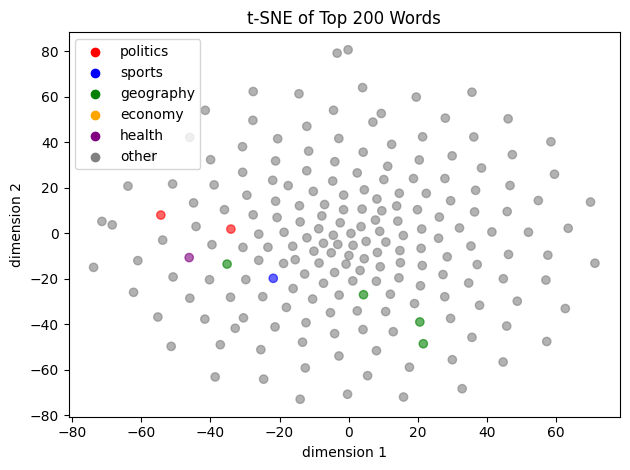

In [36]:
for color in ['red', 'blue', 'green', 'orange', 'purple', 'gray']:
    plt.scatter([], [], c=color, label=color)

plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], c=word_colors, alpha=0.6)

#adding legend
plt.legend(['politics', 'sports', 'geography', 'economy', 'health', 'other'])

plt.title('t-SNE of Top 200 Words')
plt.xlabel('dimension 1')
plt.ylabel('dimension 2')
plt.tight_layout()
plt.savefig('tsne.png')
plt.show()

#### top-5 nearest neighbours by cosine similarity
- cosine similarity function

In [39]:
def cosine_similarity(vec1, vec2):
    dot = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot / (norm1 * norm2)

- nearest neighbour function

In [41]:
def get_nearest_neighbours(query_word, matrix, word_to_index, index_to_word, top_n=5):

    #checking if query word exists
    if query_word not in word_to_index:
        print(query_word, 'not found')
        return []

    #getting query word index and vector
    query_idx = word_to_index[query_word]
    query_vec = matrix[query_idx]

    #calculating similarity with all words
    scores = []
    for i in range(len(index_to_word)):
        if i != query_idx:
            score = cosine_similarity(query_vec, matrix[i])
            scores.append((score, i))

    #sorting by score
    scores.sort(reverse=True)

    #taking top n
    results = []
    for score, idx in scores[:top_n]:
        results.append((index_to_word[idx], round(score, 4)))

    return results

- index to word mapping

In [42]:
#creating index to word mapping
index_to_word = {}

for i in range(len(ppmi_vocab)):
    index_to_word[i] = ppmi_vocab[i]

#defining 10 query words in urdu
query_words = [
    'پاکستان',
    'حکومت',
    'کرکٹ',
    'عدالت',
    'معیشت',
    'فوج',
    'صحت',
    'تعلیم',
    'پانی',
    'سکول'
]


- Top 5 nearest neighbours for each query word.

In [43]:
for qw in query_words:

    #finding neighbours
    neighbours = get_nearest_neighbours(qw, ppmi_matrix, ppmi_word_to_index, index_to_word, top_n=5)

    #printing results
    print('\nquery word:', qw)

    if neighbours:
        for word, score in neighbours:
            print('  ', word, '->', score)
    else:
        print('  word not found in vocabulary')


query word: پاکستان
   کے -> 0.2851
   انڈیا -> 0.2609
   میں -> 0.2496
   اور -> 0.2369
   کا -> 0.2334

query word: حکومت
   طالبان -> 0.258
   صوبائا -> 0.2552
   کے -> 0.2498
   وزیر -> 0.2409
   نے -> 0.2381

query word: کرکٹ
   بورڈ -> 0.3233
   کھیلنے -> 0.2474
   کھلاڑا -> 0.2416
   کپ -> 0.2266
   پاکستان -> 0.2199

query word: عدالت
   کورٹ -> 0.2413
   مقدم -> 0.2175
   جمع -> 0.2112
   سماعت -> 0.2017
   ملزمان -> 0.2

query word: معیشت
   پتی -> 0.1863
   ترقی -> 0.1741
   ملکی -> 0.1631
   ارب -> 0.1523
   روس -> 0.148

query word: فوج
   پاکستانا -> 0.2442
   فوجی -> 0.2197
   روسی -> 0.1774
   اسرائیلا -> 0.1702
   افواج -> 0.1663

query word: صحت
   مند -> 0.2471
   تولیدا -> 0.2284
   ذہنی -> 0.1924
   متعلق -> 0.1777
   مسائل -> 0.159

query word: تعلیم
   ڈگری -> 0.2109
   گریجویٹ -> 0.1811
   کالج -> 0.1726
   ڈپلومہ -> 0.1665
   یونیورسٹا -> 0.1549

query word: پانی
   گرم -> 0.251
   ٹھنڈے -> 0.1952
   گوشت -> 0.1551
   واش -> 0.1484
   بیکٹیریا -> 0.147

query 